
PaySim 移动支付欺诈检测项目报告

 一、项目背景

随着移动支付的普及，金融欺诈手段日益多样化和隐蔽化，给银行和支付机构带来了巨大的风控挑战。传统基于规则的拦截系统难以应对不断演变的欺诈模式，基于机器学习的智能风控模型成为行业趋势。
本项目基于 PaySim 模拟数据集，该数据集由金融交易模拟器生成，保留了真实移动支付交易的行为模式和欺诈特征，包含支付、转账、取现、存入等多种交易类型，并标注了每笔交易是否属于欺诈行为。项目目标是：通过数据分析和机器学习建模，识别欺诈交易的核心特征，构建具备实用价值的欺诈预测模型，为风控策略提供数据支撑。


 二、数据概述
本数据集共包含 6362620 笔交易记录，其中欺诈交易为 8213 笔，整体欺诈率为 0.1291%（约千分之 1.29）。数据呈现典型的高度不平衡特征，欺诈样本占比极低，符合真实金融风控场景中正常交易占绝大多数、欺诈交易稀少但危害巨大的业务特征。


 三、分析框架
本项目按照“结构分析、风险定位、特征画像、模型构建、策略建议”五个阶段依次展开。首先通过交易类型分布了解数据整体结构，然后聚焦欺诈交易识别其集中区域，进而从金额和时间两个维度刻画欺诈交易的特征画像，在此基础上构建机器学习模型进行欺诈预测，最终基于全部发现提出业务策略建议。


四、分析过程与发现
在交易类型分布方面，取现交易以 223万7500 笔位居第一，占比 35.17%；支付交易以 215万1495 笔紧随其后，占比 33.81%；存入交易为 139万9284 笔，占比 21.99%；转账交易为 53万2909 笔，占比 8.38%；扣款交易仅 4万1432 笔，占比 0.65%。取现和支付合计占比近 70%，是平台最主要的两种交易类型。

在欺诈交易的类型分布方面，欺诈交易 100% 集中在转账和取现两种类型中。其中，转账交易发生欺诈 4097 笔，欺诈率为 0.769%；取现交易发生欺诈 4116 笔，欺诈率为 0.184%。转账的欺诈率是取现的 4.2 倍，是欺诈风险最高的交易类型。支付、存入、扣款三种类型从未发生过欺诈交易。

在金额特征分析方面，欺诈交易的平均金额为 146.8 万元，正常交易的平均金额为 31.4 万元，欺诈交易的平均金额是正常交易的 4.7 倍。这一结果表明大额交易是欺诈的重要风险信号。但值得注意的是，正常交易中也存在最高达 9244.6 万元的超大额交易，说明金额不能作为欺诈判定的唯一标准，需结合其他特征综合判断。

进一步对欺诈交易进行金额分层分析，将欺诈交易按金额分为小额（低于1万元）、中额（1万元至50万元）和大额（高于50万元）三档。结果显示，小额欺诈 278 笔，占比 3.4%；中额欺诈 4071 笔，占比 49.6%；大额欺诈 3864 笔，占比 47.0%。中额和大额欺诈合计占比 96.6%，表明欺诈分子更倾向于一次性骗取较大金额，而非小额多次试探。

在时间维度上，对欺诈交易按小时进行分布统计，发现欺诈交易在 24 小时内分布较为均匀，每小时欺诈笔数在 274 笔至 375 笔之间波动，全天极差仅 101 笔。未发现明显的深夜集中或特定时段爆发特征，提示欺诈行为可能由自动化程序持续驱动，或欺诈者刻意模拟正常交易的时间分布模式以规避检测。

 五、模型构建与评估

在建模环节，采用随机森林算法构建欺诈预测模型。模型使用交易金额、发起方原余额、发起方新余额、接收方原余额、接收方新余额、交易类型编码、发起方余额变化、接收方余额变化共八个特征进行训练，按 70% 训练集、30% 测试集的比例划分数据。

模型在测试集上的表现良好，AUC 值达到 0.9817，表明模型具备优秀的欺诈与正常交易区分能力。在默认阈值 0.5 下，模型的精确率为 98%，召回率为 71%，F1分数为 0.82。考虑到风控场景中漏报欺诈的代价远高于误报正常交易，本报告对分类阈值进行了优化调整。当阈值调低至 0.3 时，召回率提升至 76%，精确率保持在 91% 的可用水平，F1 分数提升至 0.83，实现了误报与漏报的更优平衡。当阈值进一步降至 0.2 时，召回率可达 80%，但精确率降至 83%，误报成本显著增加。综合考虑，推荐在实际业务中采用 0.3 作为分类阈值。

通过特征重要性分析发现，发起方账户余额变化是对欺诈判断贡献最大的特征，重要性为 0.232；其次是交易金额，重要性为 0.154；接收方余额变化位列第三，重要性为 0.133。这一结果验证了业务直觉，即欺诈交易的核心模式是资金从发起方快速、大量地转移，发起方账户余额大幅下降甚至归零，同时接收方账户收到异常大额资金。


 六、结论与建议

基于以上分析，本报告得出以下核心结论。第一，欺诈交易高度集中在转账和取现两种类型中，其中转账的欺诈率是取现的 4.2 倍，是最需要重点关注的高风险交易类型。第二，金额是区分欺诈与正常交易的重要信号，欺诈交易平均金额是正常的 4.7 倍，中额和大额欺诈合计占比超过 96%。第三，欺诈交易在时间上无明显的集中特征，全天分布均匀，可能由自动化程序驱动。第四，随机森林模型在风控场景中具备实用价值，AUC 达到 0.9817，在推荐阈值 0.3 下可拦截约 76% 的欺诈交易，同时保持 91% 的精确率。第五，发起方账户余额变化是最关键的预测特征，核心风险模式为“账户资金快速大量流出”。

基于上述结论，提出以下业务建议。在交易类型监控方面，应对转账和取现交易设置更严格的风控规则，而支付、存入、扣款三类交易可适当简化审核流程。在金额分层策略方面，对中额交易重点监控行为模式，对大额交易设置人工复核或二次验证环节，同时建议建立小额异常交易的监测机制作为早期预警信号。在异常账户监测方面，应重点关注余额短期内大幅减少的账户，建立“账户清零”预警机制。在模型部署方面，建议采用 0.3 的分类阈值，对实时交易中欺诈概率超过 30% 的交易进行拦截。

后续优化可从三个方向展开：引入时序特征捕捉账户行为的时序异常，基于交易对手方信息构建图关系网络以识别团伙欺诈，以及通过网格搜索等方法进一步优化模型超参数。


 七、项目技术栈

本项目使用的技术工具包括：MySQL 作为数据库存储交易数据，Python 的 pandas 和 NumPy 完成数据处理与特征工程，matplotlib 和 seaborn 完成数据可视化，scikit-learn 完成随机森林模型的构建与评估，Jupyter Notebook 作为开发环境。


以下是具体内容

In [1]:
import pandas as pd

file_path = 'C:/Users/SHY/Desktop/研究生秋招/xm/PS_20174392719_1491204439457_log.csv'

df_sample = pd.read_csv(file_path, nrows=100000)
df_sample.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
print(len(df_sample))

100000


In [3]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            100000 non-null  int64  
 1   type            100000 non-null  object 
 2   amount          100000 non-null  float64
 3   nameOrig        100000 non-null  object 
 4   oldbalanceOrg   100000 non-null  float64
 5   newbalanceOrig  100000 non-null  float64
 6   nameDest        100000 non-null  object 
 7   oldbalanceDest  100000 non-null  float64
 8   newbalanceDest  100000 non-null  float64
 9   isFraud         100000 non-null  int64  
 10  isFlaggedFraud  100000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 8.4+ MB


In [4]:
!pip install pymysql

In [5]:
import pymysql
import pandas as pd

# 连接数据库
conn = pymysql.connect(
    host='localhost',
    user='root',
    password='29590157',  # 改成你自己的密码
    database='bank_data',
    charset='utf8mb4'
)

# 获取游标
cursor = conn.cursor()

# 插入数据的 SQL（占位符 %s）
insert_sql = """
INSERT INTO paysim1_transactions (
    step, type, amount, nameOrig, oldbalanceOrg, newbalanceOrig,
    nameDest, oldbalanceDest, newbalanceDest, isFraud, isFlaggedFraud
) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

# 把 DataFrame 转成列表，逐行插入
data_to_insert = df_sample.values.tolist()

# 执行批量插入
cursor.executemany(insert_sql, data_to_insert)
conn.commit()

print(f"成功插入 {len(data_to_insert)} 行数据！")

# 关闭连接
cursor.close()#conn 只是一个“通道”，它负责连接你和数据库，但它本身不会执行指令。需要一个“操作员”来帮你干活，这个操作员就是 cursor。
conn.close()

成功插入 100000 行数据！


In [16]:
cursor = conn.cursor()
cursor.execute("TRUNCATE TABLE paysim1_transactions;")
conn.commit()
cursor.close()
print("✅ 表已清空")

✅ 表已清空


In [17]:
import pymysql
import pandas as pd

# 连接数据库
conn = pymysql.connect(
    host='localhost',
    user='root',
    password='29590157',  
    database='bank_data',
    charset='utf8mb4'
)

cursor = conn.cursor()

# SQL 插入模板
insert_sql = """
INSERT INTO paysim1_transactions (
    step, type, amount, nameOrig, oldbalanceOrg, newbalanceOrig,
    nameDest, oldbalanceDest, newbalanceDest, isFraud, isFlaggedFraud
) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

# 文件路径（改成你自己的）
file_path = 'C:/Users/SHY/Desktop/研究生秋招/xm/PS_20174392719_1491204439457_log.csv'

# 分块读取并插入
chunk_size = 100000
total_rows = 0

for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    data_to_insert = chunk.values.tolist()
    cursor.executemany(insert_sql, data_to_insert)
    conn.commit()
    total_rows += len(data_to_insert)
    print(f"已插入 {total_rows} 行...")

print(f"✅ 全量导入完成！共插入 {total_rows} 行")

cursor.close()
conn.close()

已插入 100000 行...
已插入 200000 行...
已插入 300000 行...
已插入 400000 行...
已插入 500000 行...
已插入 600000 行...
已插入 700000 行...
已插入 800000 行...
已插入 900000 行...
已插入 1000000 行...
已插入 1100000 行...
已插入 1200000 行...
已插入 1300000 行...
已插入 1400000 行...
已插入 1500000 行...
已插入 1600000 行...
已插入 1700000 行...
已插入 1800000 行...
已插入 1900000 行...
已插入 2000000 行...
已插入 2100000 行...
已插入 2200000 行...
已插入 2300000 行...
已插入 2400000 行...
已插入 2500000 行...
已插入 2600000 行...
已插入 2700000 行...
已插入 2800000 行...
已插入 2900000 行...
已插入 3000000 行...
已插入 3100000 行...
已插入 3200000 行...
已插入 3300000 行...
已插入 3400000 行...
已插入 3500000 行...
已插入 3600000 行...
已插入 3700000 行...
已插入 3800000 行...
已插入 3900000 行...
已插入 4000000 行...
已插入 4100000 行...
已插入 4200000 行...
已插入 4300000 行...
已插入 4400000 行...
已插入 4500000 行...
已插入 4600000 行...
已插入 4700000 行...
已插入 4800000 行...
已插入 4900000 行...
已插入 5000000 行...
已插入 5100000 行...
已插入 5200000 行...
已插入 5300000 行...
已插入 5400000 行...
已插入 5500000 行...
已插入 5600000 行...
已插入 5700000 行...
已插入 5800000 行...
已插入 5900000 行...
已插入 60

In [18]:
# 重新连接
conn = pymysql.connect(
    host='localhost',
    user='root',
    password='29590157',
    database='bank_data',
    charset='utf8mb4'
)

cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM paysim1_transactions;")
count = cursor.fetchone()[0]
cursor.close()
print(f"当前表中共有 {count:,} 行数据")

当前表中共有 6,362,620 行数据


✅ 重新连接成功！


In [19]:
#1.欺诈率

query = """
SELECT 
    COUNT(*) AS total_rows,
    SUM(isFraud) AS fraud_count,
    ROUND(SUM(isFraud) * 100.0 / COUNT(*), 4) AS fraud_rate_pct
FROM paysim1_transactions;
"""

df_summary = pd.read_sql(query, conn)
display(df_summary)

,total_rows,fraud_count,fraud_rate_pct
0,6362620,8213.0,0.1291



=== 交易类型占比 ===


,type,cnt,占比
0,CASH_OUT,2237500,35.17
1,PAYMENT,2151495,33.81
2,CASH_IN,1399284,21.99
3,TRANSFER,532909,8.38
4,DEBIT,41432,0.65


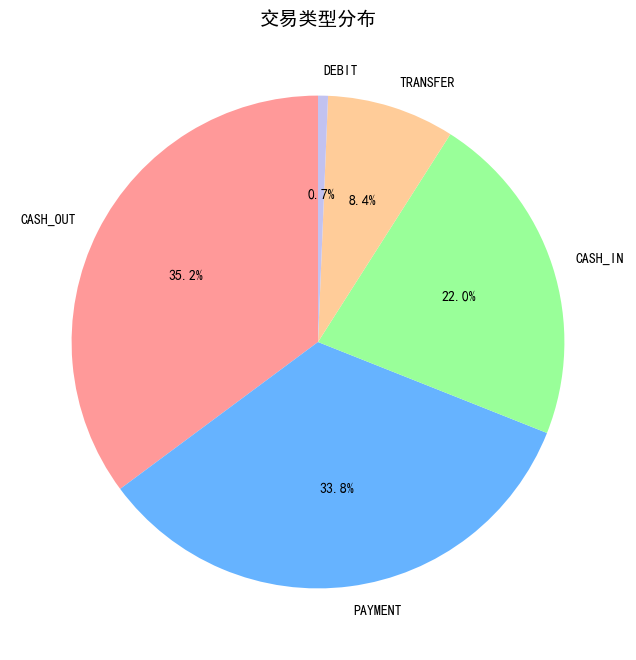

In [22]:

#2.每种交易类型占比
import matplotlib.pyplot as plt
import pandas as pd

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 查询数据（你已经有了 df_types，但如果没定义就重新查一下）
query = """
SELECT type, COUNT(*) AS cnt
FROM paysim1_transactions
GROUP BY type
ORDER BY cnt DESC;
"""

df_types = pd.read_sql(query, conn)

# 计算占比
df_types['占比'] = (df_types['cnt'] / df_types['cnt'].sum() * 100).round(2)

# 显示占比表格
print("\n=== 交易类型占比 ===")
display(df_types)

# 画饼图
plt.figure(figsize=(8, 8))
plt.pie(
    df_types['cnt'],
    labels=df_types['type'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0']
)
plt.title('交易类型分布', fontsize=14)
plt.show()

In [23]:
# 3.查询每种类型中欺诈率占比
query = """
SELECT 
    type, 
    COUNT(*) AS total_cnt,
    SUM(isFraud) AS fraud_cnt,
    ROUND(SUM(isFraud) * 100.0 / COUNT(*), 4) AS fraud_rate_pct
FROM paysim1_transactions
GROUP BY type
ORDER BY fraud_cnt DESC;
"""

df_fraud_by_type = pd.read_sql(query, conn)
display(df_fraud_by_type)


,type,total_cnt,fraud_cnt,fraud_rate_pct
0,CASH_OUT,2237500,4116.0,0.1840
1,TRANSFER,532909,4097.0,0.7688
2,PAYMENT,2151495,0.0,0.0000
3,DEBIT,41432,0.0,0.0000
4,CASH_IN,1399284,0.0,0.0000


In [24]:
# 4.金额特征对比
#验证：欺诈交易是不是比正常交易“更大笔”？如果金额越大风险越高，那么金额就可以作为风控的重要特征。
query = """
SELECT
    isFraud,
    COUNT(*) AS cnt,
    ROUND(AVG(amount), 2) AS avg_amount,
    ROUND(MAX(amount), 2) AS max_amount,
    ROUND(MIN(amount), 2) AS min_amount,
    ROUND(SUM(amount), 2) AS total_amount
FROM paysim1_transactions
WHERE type IN ('TRANSFER', 'CASH_OUT')
GROUP BY isFraud;
"""

df_amount_compare = pd.read_sql(query, conn)
display(df_amount_compare)

#结论通过对欺诈交易与正常交易的金额进行对比分析发现，欺诈交易的平均金额（146.8 万元）显著高于正常交易（31.4 万元），约为后者的 4.7 倍，表明大额交易是欺诈风险的重要识别信号。

#但同时，正常交易中最大金额（9244.6 万元）远高于欺诈交易最大值（1000 万元），说明金额并非欺诈判定的唯一标准，需结合交易类型、交易频次、对手方特征等多维信息进行综合判断，以降低误判率。

#此外，欺诈交易中存在金额为 0 的异常交易，此类“零金额”交易模式也应纳入风控监控范围。

,isFraud,cnt,avg_amount,max_amount,min_amount,total_amount
0,1,8213,1467967.3,10000000.00,0.00,1.205642e+10
1,0,2762196,314115.5,92445516.64,0.01,8.676486e+11


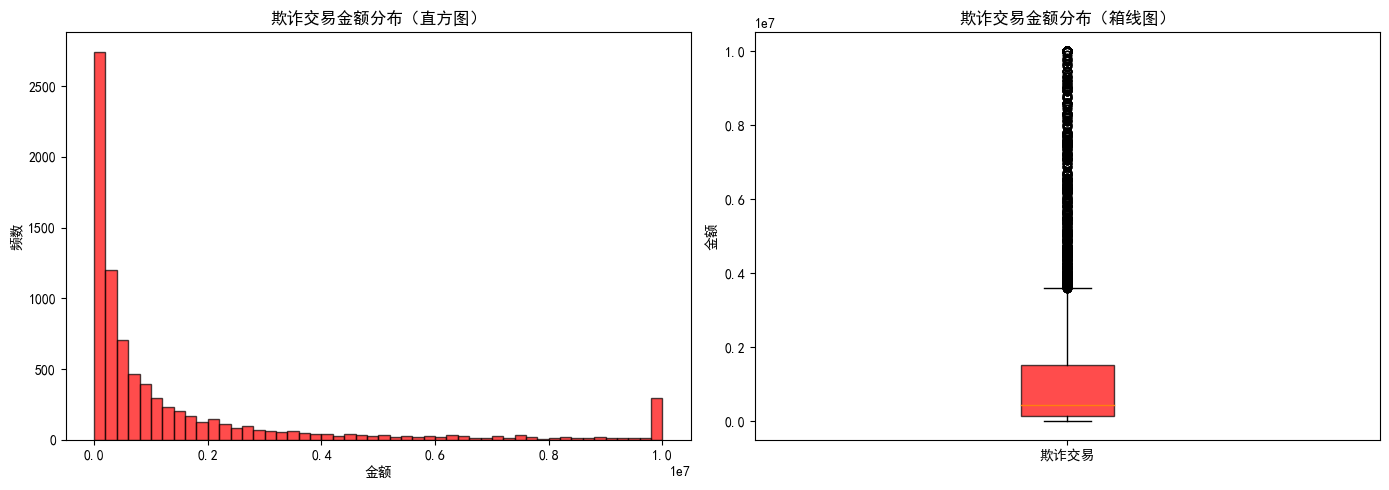

=== 欺诈交易金额统计 ===
总笔数: 8,213
平均金额: 1,467,967.30
中位数: 441,423.44
最小值: 0.00
最大值: 10,000,000.00
25%分位数: 127,091.33
75%分位数: 1,517,771.48


In [25]:
#5.欺诈交易金额分布
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 提取欺诈交易的金额
query = """
SELECT amount
FROM paysim1_transactions
WHERE isFraud = 1
LIMIT 10000;
"""

df_fraud_amount = pd.read_sql(query, conn)

# 创建画布，并排显示两个图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1：直方图
axes[0].hist(df_fraud_amount['amount'], bins=50, color='red', edgecolor='black', alpha=0.7)
axes[0].set_title('欺诈交易金额分布（直方图）')
axes[0].set_xlabel('金额')
axes[0].set_ylabel('频数')

# 图2：箱线图
axes[1].boxplot(df_fraud_amount['amount'], vert=True, patch_artist=True, 
                boxprops=dict(facecolor='red', alpha=0.7))
axes[1].set_title('欺诈交易金额分布（箱线图）')
axes[1].set_ylabel('金额')
axes[1].set_xticklabels(['欺诈交易'])

plt.tight_layout()
plt.show()

# 打印关键统计量
print("=== 欺诈交易金额统计 ===")
print(f"总笔数: {len(df_fraud_amount):,}")
print(f"平均金额: {df_fraud_amount['amount'].mean():,.2f}")
print(f"中位数: {df_fraud_amount['amount'].median():,.2f}")
print(f"最小值: {df_fraud_amount['amount'].min():,.2f}")
print(f"最大值: {df_fraud_amount['amount'].max():,.2f}")
print(f"25%分位数: {df_fraud_amount['amount'].quantile(0.25):,.2f}")
print(f"75%分位数: {df_fraud_amount['amount'].quantile(0.75):,.2f}")

#欺诈交易金额分布呈现“右偏”特征：（尾巴在右边所以叫右偏

#多数欺诈交易集中在 0～50 万元区间，笔数占比超过 70%；

#平均金额被少数极端大额交易（如 1000 万元）拉高至 146.8 万元，而中位数仅为 44.1 万元；

#表明风控策略应对不同金额区间采取差异化措施：对小额交易可采取轻量化拦截（如短信验证），对超500万的大额交易则应设置人工复核环节。

=== TRANSFER vs CASH_OUT 欺诈金额对比 ===


,type,笔数,平均值,中位数,最小值,最大值,25%分位数,75%分位数
0,CASH_OUT,4116,1.455103e+06,435516.905,0.0,10000000.0,125464.45,1500761.03
1,TRANSFER,4097,1.480892e+06,445705.760,63.8,10000000.0,128417.96,1534985.07


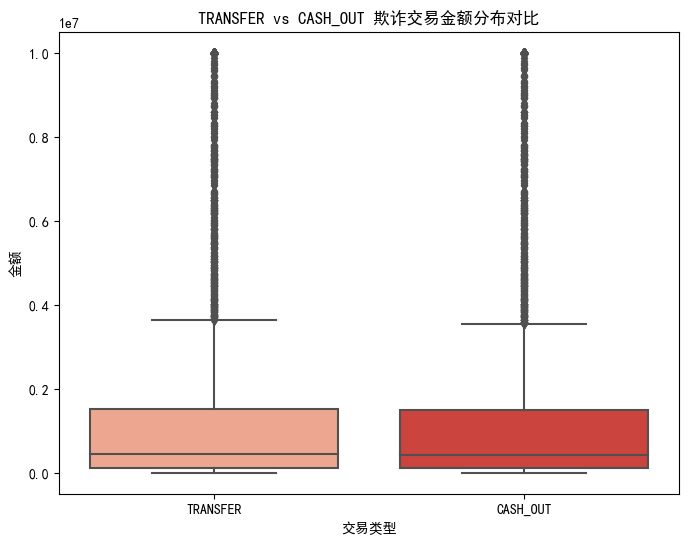

In [26]:
#6.交易类型与欺诈金额的交叉分析、具体情况 
# 提取 TRANSFER 和 CASH_OUT 的欺诈交易金额
query = """
SELECT 
    type,
    amount
FROM paysim1_transactions
WHERE isFraud = 1 
    AND type IN ('TRANSFER', 'CASH_OUT');
"""

df_fraud_type_amount = pd.read_sql(query, conn)

# 按类型分组统计
summary = df_fraud_type_amount.groupby('type')['amount'].agg([
    ('笔数', 'count'),
    ('平均值', 'mean'),
    ('中位数', 'median'),
    ('最小值', 'min'),
    ('最大值', 'max'),
    ('25%分位数', lambda x: x.quantile(0.25)),
    ('75%分位数', lambda x: x.quantile(0.75))
]).reset_index()

# 显示统计表格
print("=== TRANSFER vs CASH_OUT 欺诈金额对比 ===")
display(summary)

# 画箱线图对比
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_fraud_type_amount, x='type', y='amount', palette='Reds')
plt.title('TRANSFER vs CASH_OUT 欺诈交易金额分布对比')
plt.xlabel('交易类型')
plt.ylabel('金额')
plt.show()

#交易类型与欺诈金额的交叉分析：

#TRANSFER 与 CASH_OUT 两种高风险交易类型的欺诈金额分布高度相似，平均金额分别约为 148.1 万元和 145.5 万元，中位数均在 44 万元左右。

#这一结果表明：两类交易的欺诈金额特征无明显差异，风控策略可统一设置金额阈值，无需针对不同交易类型进行差异化金额管控。

#值得注意的差异点是：CASH_OUT 类型中存在 0 元欺诈交易，提示该类型可能存在异常交易模式（如测试交易、空壳账户操作），建议在风控规则中单独标记。

In [27]:
#此处跳过一些，直接到模型（因为要回去睡觉

In [34]:
#OK啊，第二天了，继续补充一些必要的分析

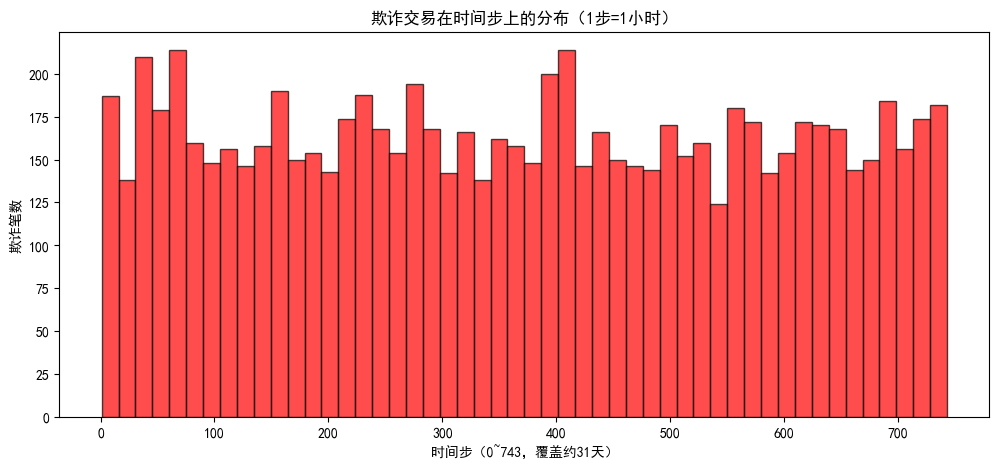

欺诈交易总笔数: 8213
时间步范围: 1 ~ 743
=== 每小时欺诈交易笔数（0~23点）===
 0点:  300笔 ██████████████████████████████
 1点:  358笔 ███████████████████████████████████
 2点:  372笔 █████████████████████████████████████
 3点:  326笔 ████████████████████████████████
 4点:  274笔 ███████████████████████████
 5点:  366笔 ████████████████████████████████████
 6点:  358笔 ███████████████████████████████████
 7点:  328笔 ████████████████████████████████
 8点:  368笔 ████████████████████████████████████
 9点:  341笔 ██████████████████████████████████
10点:  375笔 █████████████████████████████████████
11点:  324笔 ████████████████████████████████
12点:  339笔 █████████████████████████████████
13点:  346笔 ██████████████████████████████████
14点:  353笔 ███████████████████████████████████
15点:  341笔 ██████████████████████████████████
16点:  345笔 ██████████████████████████████████
17点:  353笔 ███████████████████████████████████
18点:  343笔 ██████████████████████████████████
19点:  342笔 ██████████████████████████████████
20点:  340笔 ████████████████████

In [36]:
# 7. 欺诈交易的时间分布
import matplotlib.pyplot as plt
import pandas as pd

query = """
SELECT step, amount, type
FROM paysim1_transactions
WHERE isFraud = 1;
"""

df_fraud_time = pd.read_sql(query, conn)

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 5))
plt.hist(df_fraud_time['step'], bins=50, color='red', edgecolor='black', alpha=0.7)
plt.title('欺诈交易在时间步上的分布（1步=1小时）')
plt.xlabel('时间步（0~743，覆盖约31天）')
plt.ylabel('欺诈笔数')
plt.show()

print(f"欺诈交易总笔数: {len(df_fraud_time)}")
print(f"时间步范围: {df_fraud_time['step'].min()} ~ {df_fraud_time['step'].max()}")



# 按小时（0~23）统计欺诈交易笔数
df_fraud_time['hour'] = df_fraud_time['step'] % 24
hourly_fraud = df_fraud_time['hour'].value_counts().sort_index()

print("=== 每小时欺诈交易笔数（0~23点）===")
for hour, count in hourly_fraud.items():
    bar = '█' * (count // 10)  # 每10笔画一个█，方便看
    print(f"{hour:2d}点: {count:4d}笔 {bar}")

print(f"\n欺诈最多的前3个时段:")
print(hourly_fraud.nlargest(3))

#时间维度分析：欺诈交易在 24 小时内分布均匀（每小時约 270~375 笔），未发现明显的“深夜集中”特征。
#据此判断，交易时间不宜作为独立风控规则，但可作为辅助特征，结合账户历史行为进行异常检测

=== 欺诈交易金额分层统计 ===
小额 (<1万):  278 笔 (3.4%)
中额 (1万~50万): 4071 笔 (49.6%)
大额 (>50万): 3864 笔 (47.0%)


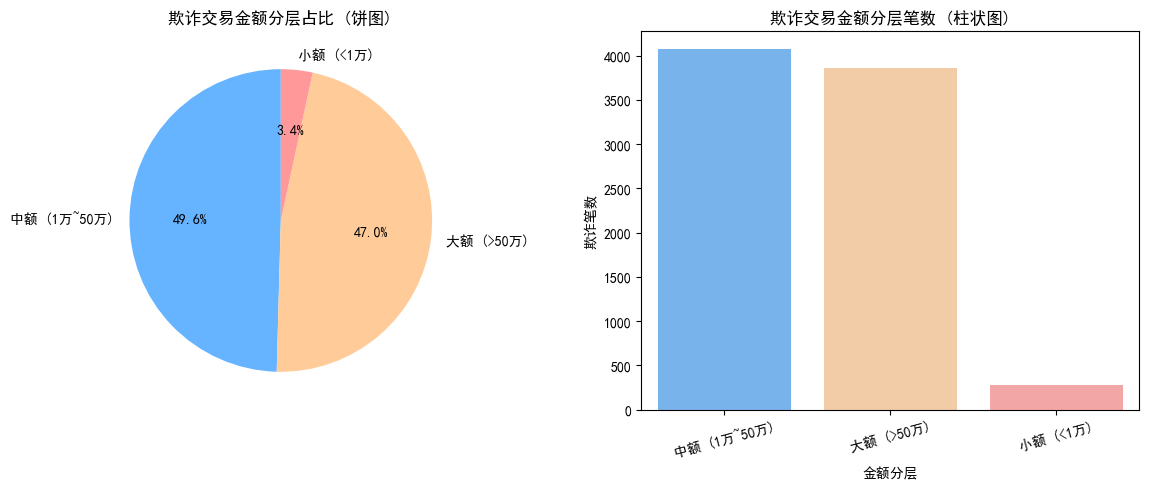

In [37]:

#8. 欺诈金额大小分层
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 提取欺诈交易金额（从已有数据 df_fraud_amount 中来）
# 如果 df_fraud_amount 还没定义，先查一下：
if 'df_fraud_amount' not in dir():#目录
    query = "SELECT amount FROM paysim1_transactions WHERE isFraud = 1;"
    df_fraud_amount = pd.read_sql(query, conn)

# 定义金额分层函数
def amount_level(amount):
    if amount < 10000:
        return '小额 (<1万)'
    elif amount < 500000:
        return '中额 (1万~50万)'
    else:
        return '大额 (>50万)'

# 应用分层
df_fraud_amount['amount_level'] = df_fraud_amount['amount'].apply(amount_level)

# 统计各层数量
level_counts = df_fraud_amount['amount_level'].value_counts()
level_percent = df_fraud_amount['amount_level'].value_counts(normalize=True) * 100
#这行代码的作用是：统计各金额分层在欺诈交易中的占比，并把结果转成百分比，方便解读和展示。


# 显示结果
print("=== 欺诈交易金额分层统计 ===")
for level in ['小额 (<1万)', '中额 (1万~50万)', '大额 (>50万)']:
    count = level_counts.get(level, 0)
    pct = level_percent.get(level, 0)
    print(f"{level}: {count:4d} 笔 ({pct:.1f}%)")

# 画图
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 饼图
axes[0].pie(
    level_counts.values, 
    labels=level_counts.index, 
    autopct='%1.1f%%', 
    startangle=90,
    colors=['#66b3ff', '#ffcc99', '#ff9999']
)
axes[0].set_title('欺诈交易金额分层占比 (饼图)')

# 柱状图
sns.barplot(
    x=level_counts.index, 
    y=level_counts.values, 
    palette=['#66b3ff', '#ffcc99', '#ff9999'],
    ax=axes[1]
)
axes[1].set_title('欺诈交易金额分层笔数 (柱状图)')
axes[1].set_xlabel('金额分层')
axes[1].set_ylabel('欺诈笔数')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

#金额分层分析：对 8,213 笔欺诈交易按金额进行分层统计，
#结果显示：中额（1万~50万）欺诈占比 49.6%，大额（>50万）欺诈占比 47.0%，两者合计占总欺诈笔数的 96.6%，而小额（<1万）欺诈仅占 3.4%。

#这表明欺诈分子更倾向于一次性骗取较大金额，而非小额多次试探。
#建议风控策略针对中额和大额区间分别设置差异化阈值，并建立小额异常交易的监测机制以提前发现潜在欺诈行为。

In [30]:
!pip install scikit-learn -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ---------------------------------------- 7.1/7.1 MB 9.3 MB/s eta 0:00:00
     -------------------------------------- 302.2/302.2 kB 1.6 MB/s eta 0:00:00


In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 提取建模数据（只取TRANSFER和CASH_OUT）
query = """
SELECT 
    type,
    amount,
    oldbalanceOrg,
    newbalanceOrig,
    oldbalanceDest,
    newbalanceDest,
    isFraud
FROM paysim1_transactions
WHERE type IN ('TRANSFER', 'CASH_OUT')
LIMIT 500000;
"""

df_model = pd.read_sql(query, conn)
print(f"数据量: {len(df_model)} 行")

数据量: 500000 行


In [32]:
# 特征工程：将分类变量转换为数值
df_model['type_encoded'] = df_model['type'].map({'CASH_OUT': 0, 'TRANSFER': 1})

# 构造新特征：交易前后的余额变化
df_model['balance_change_org'] = df_model['oldbalanceOrg'] - df_model['newbalanceOrig']
df_model['balance_change_dest'] = df_model['oldbalanceDest'] - df_model['newbalanceDest']

# 选择特征列（X）和目标列（y）
features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 
            'newbalanceDest', 'type_encoded', 'balance_change_org', 'balance_change_dest']
X = df_model[features]
y = df_model['isFraud']

print("特征工程完成！")
print(f"特征数量: {len(features)}")
print(f"特征名称: {features}")

特征工程完成！
特征数量: 8
特征名称: ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'type_encoded', 'balance_change_org', 'balance_change_dest']


In [38]:
# 切分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 训练随机森林模型（经典算法，适合处理不平衡数据）
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 预测与评估
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("=== 模型评估 ===")
print(f"AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\n分类报告:")
print(classification_report(y_test, y_pred, target_names=['正常', '欺诈']))

=== 模型评估 ===
AUC: 0.9817

分类报告:
              precision    recall  f1-score   support

          正常       1.00      1.00      1.00    149531
          欺诈       0.98      0.71      0.82       469

    accuracy                           1.00    150000
   macro avg       0.99      0.86      0.91    150000
weighted avg       1.00      1.00      1.00    150000



In [41]:
# 设置新阈值
threshold = 0.3

# 根据欺诈概率重新生成预测结果
y_pred_new = (y_proba >= threshold).astype(int)

# 评估新阈值下的效果
from sklearn.metrics import classification_report

print(f"=== 阈值 = {threshold} 时的模型表现 ===")
print(classification_report(y_test, y_pred_new, target_names=['正常', '欺诈']))

=== 阈值 = 0.3 时的模型表现 ===
              precision    recall  f1-score   support

          正常       1.00      1.00      1.00    149531
          欺诈       0.91      0.76      0.83       469

    accuracy                           1.00    150000
   macro avg       0.96      0.88      0.91    150000
weighted avg       1.00      1.00      1.00    150000



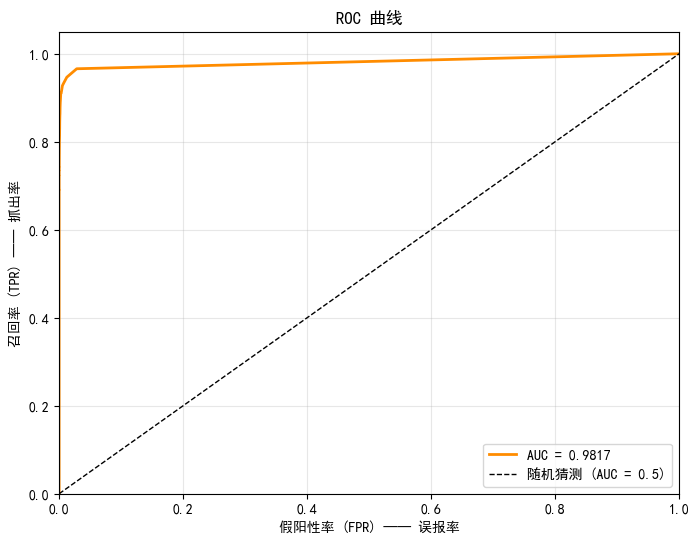

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 计算 ROC 曲线的数据
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

# 画图
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}', linewidth=2, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='随机猜测 (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假阳性率 (FPR) —— 误报率')
plt.ylabel('召回率 (TPR) —— 抓出率')
plt.title('ROC 曲线')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

=== 特征重要性排序 ===
                    特征       重要性
6   balance_change_org  0.232427
0               amount  0.154221
7  balance_change_dest  0.132785
1        oldbalanceOrg  0.126026
5         type_encoded  0.119450
4       newbalanceDest  0.096086
3       oldbalanceDest  0.086984
2       newbalanceOrig  0.052020


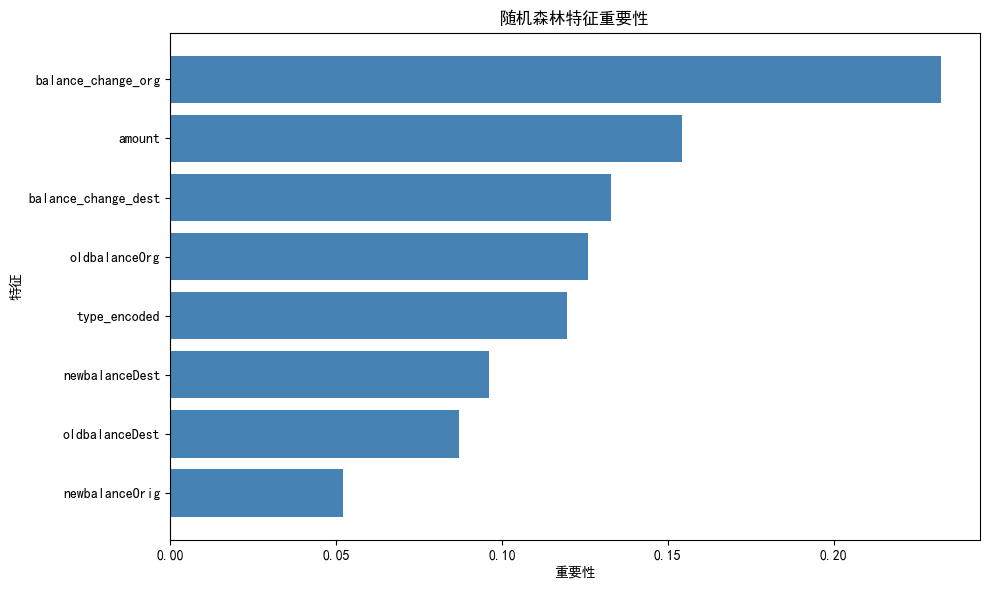

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 提取特征重要性
importance_df = pd.DataFrame({
    '特征': features,
    '重要性': model.feature_importances_
}).sort_values('重要性', ascending=False)

# 打印表格
print("=== 特征重要性排序 ===")
print(importance_df)

# 画柱状图
plt.figure(figsize=(10, 6))
plt.barh(importance_df['特征'], importance_df['重要性'], color='steelblue')
plt.xlabel('重要性')
plt.ylabel('特征')
plt.title('随机森林特征重要性')
plt.gca().invert_yaxis()  # 重要性高的放在最上面
plt.tight_layout()
plt.show()


#看每个特征在所有决策树中，被用来“分裂”节点的次数和效果。如果一个特征频繁被用来做决策，并且每次分裂都能带来很好的分类效果，它的重要性就高。